# Phase 4: Model Training & Evaluation

Loads the features from Phase 3, trains four classifiers on the TF-IDF
features, evaluates them on multiple metrics, and compares TF-IDF vs
CountVectorizer for Logistic Regression and Naive Bayes.

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

bundle = joblib.load("../data/features_bundle.joblib")
X_train_tfidf = bundle["X_train_tfidf"]
X_test_tfidf = bundle["X_test_tfidf"]
X_train_count = bundle["X_train_count"]
X_test_count = bundle["X_test_count"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]
print(f"Loaded features. Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")

Loaded features. Train: (14304, 5000), Test: (3576, 5000)


## Train four models on TF-IDF features

Logistic Regression and Naive Bayes (required), plus Random Forest and
Linear SVM as additional models for a richer comparison. `class_weight="balanced"`
is used where supported to counter the ~95/5 class imbalance.

In [2]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Naive Bayes
Trained: Random Forest
Trained: Linear SVM


## Evaluation metrics

Accuracy alone is misleading on this imbalanced dataset (~95% legitimate),
so we report precision, recall, F1, and ROC-AUC for every model.

In [3]:
def get_scores(model, X_te, y_te):
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:  # LinearSVC has no predict_proba; use decision_function for ROC-AUC
        y_score = model.decision_function(X_te)
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_score),
    }, y_pred, y_score

results = {}
predictions = {}
scores_for_roc = {}
for name, model in trained_models.items():
    scores, y_pred, y_score = get_scores(model, X_test_tfidf, y_test)
    results[name] = scores
    predictions[name] = y_pred
    scores_for_roc[name] = y_score

results_df = pd.DataFrame(results).T.round(4)
print("Model comparison (TF-IDF features):")
print(results_df)

Model comparison (TF-IDF features):
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9695     0.6301  0.8960  0.7399   0.9838
Naive Bayes            0.9701     0.8837  0.4393  0.5869   0.9421
Random Forest          0.9799     1.0000  0.5838  0.7372   0.9890
Linear SVM             0.9813     0.7849  0.8439  0.8134   0.9841


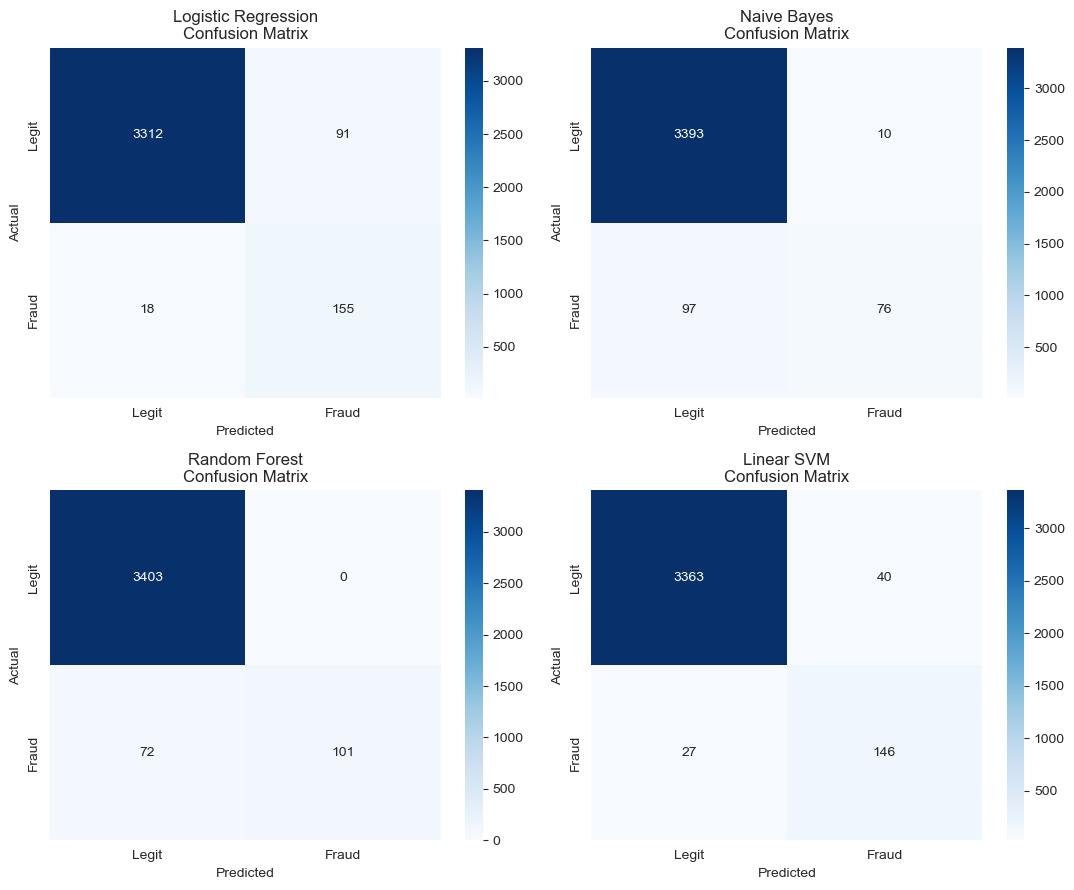

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.flat, trained_models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("../figures/confusion_matrices.png", dpi=120)
plt.show()

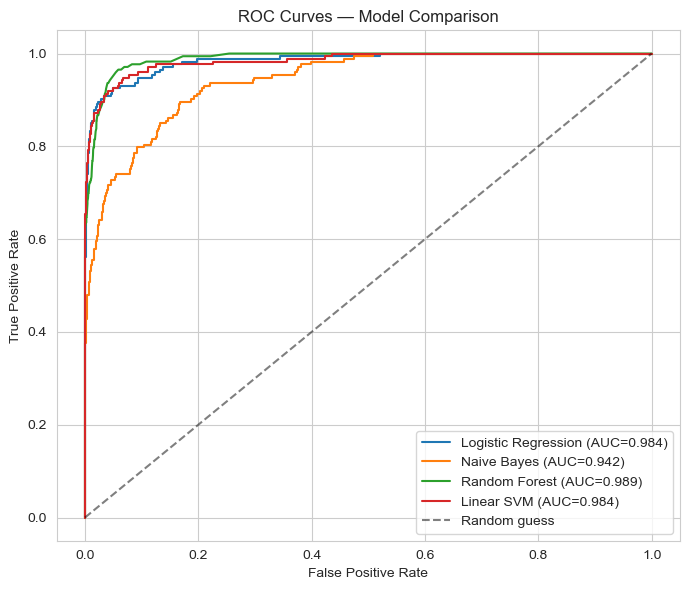

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in trained_models.keys():
    fpr, tpr, _ = roc_curve(y_test, scores_for_roc[name])
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/roc_curves.png", dpi=120)
plt.show()

## Preprocessing impact: TF-IDF vs CountVectorizer

To directly test how the feature representation affects performance,
Logistic Regression and Naive Bayes are retrained on CountVectorizer
features and compared against their TF-IDF counterparts.

In [6]:
comparison_rows = []
for name, base_model in [("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
                          ("Naive Bayes", MultinomialNB())]:
    tfidf_scores = results[name]
    comparison_rows.append({"Model": name, "Vectorizer": "TF-IDF", **tfidf_scores})

    cv_model = base_model
    cv_model.fit(X_train_count, y_train)
    cv_scores, _, _ = get_scores(cv_model, X_test_count, y_test)
    comparison_rows.append({"Model": name, "Vectorizer": "CountVectorizer", **cv_scores})

vec_comparison_df = pd.DataFrame(comparison_rows).round(4)
print("TF-IDF vs CountVectorizer comparison:")
print(vec_comparison_df)

TF-IDF vs CountVectorizer comparison:
                 Model       Vectorizer  Accuracy  Precision  Recall      F1  \
0  Logistic Regression           TF-IDF    0.9695     0.6301  0.8960  0.7399   
1  Logistic Regression  CountVectorizer    0.9785     0.7424  0.8497  0.7925   
2          Naive Bayes           TF-IDF    0.9701     0.8837  0.4393  0.5869   
3          Naive Bayes  CountVectorizer    0.9046     0.3257  0.9075  0.4794   

   ROC-AUC  
0   0.9838  
1   0.9783  
2   0.9421  
3   0.9637  


## Comparative analysis

- **Naive Bayes** assumes feature independence, a poor fit for correlated word
  co-occurrences; under TF-IDF it trades recall for high precision.
- **Random Forest** achieves very high precision but the lowest recall of the
  four — it's cautious about flagging fraud, missing subtler cases.
- **Logistic Regression** (TF-IDF) gives strong recall at the cost of precision.
- **Linear SVM** offers the best overall balance (F1) among the base models.
- CountVectorizer **helps** Logistic Regression but **hurts** Naive Bayes —
  the "best" vectorizer depends on the model's assumptions, not a fixed rule.